In [3]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

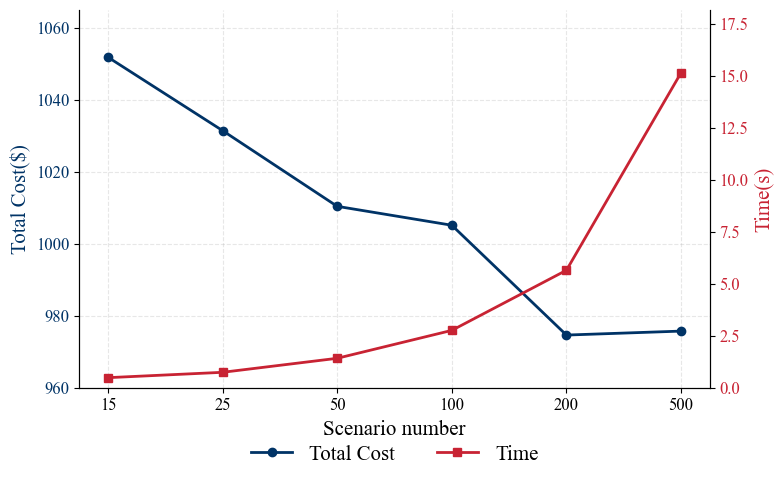

In [25]:
data = {
    'Sample Size': [500, 200, 100, 50, 25, 15],
    'Total Cost': [975.81, 974.71, 1005.18, 1010.43, 1031.44, 1051.81],
    'Penalty': [0, 0, 0, 0, 0, 9],
    'Time': [1454.92, 543.58, 266.2, 137.39, 72.75, 48]
}

df = pd.DataFrame(data)

df = df.sort_values(by='Sample Size', ascending=True)
df['Time'] = df['Time'] / 96  # 时间除以 96

plt.rcParams['font.family'] = 'serif'  # 切换为衬线字体族
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif'] # 指定使用 Times New Roman
plt.rcParams['mathtext.fontset'] = 'stix' # 让数字和数学符号也看起来像 LaTeX/论文印刷体

# plt.rcParams['font.size'] = 12
# plt.rcParams['axes.titlesize'] = 14
# plt.rcParams['axes.labelsize'] = 12
# 将 Sample Size 转为字符串作为 X 轴标签
x_positions = range(len(df))
x_labels = df['Sample Size'].astype(str)

# 3. 创建画布
fig, ax1 = plt.subplots(figsize=(8, 5))

# --- 配色 ---
color_cost = '#003366'  # 海军蓝
color_time = '#C82333'  # Brick Red (深红)

# --- 绘制左轴 (Total Cost) ---
ax1.set_xlabel('Scenario number', fontsize=15)
ax1.set_ylabel('Total Cost($)', color=color_cost, fontsize=15)
ax1.plot(x_positions, df['Total Cost'], color=color_cost, marker='o', 
         linewidth=2, label='Total Cost')
ax1.tick_params(axis='y', labelcolor=color_cost)
# 设置左轴范围，留出空间显示标签
ax1.set_ylim(960, 1065)

# --- 绘制右轴 (Time / 96) ---
ax2 = ax1.twinx()
ax2.set_ylabel('Time(s)', color=color_time, fontsize=15)
ax2.plot(x_positions, df['Time'], color=color_time, marker='s', 
         linestyle='-', linewidth=2, label='Time')
ax2.tick_params(axis='y', labelcolor=color_time)

# 设置右轴范围，留出空间显示标签
ax2.set_ylim(0, df['Time'].max() * 1.2)


ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
# --- 格式化 X 轴 ---
plt.xticks(x_positions, x_labels, fontsize=15)

# --- 图例与标题 ---
# plt.title('Sensitivity Analysis: Sample Size Impact', fontsize=14, pad=20)
ax1.grid(True, linestyle='--', alpha=0.3)

# 合并图例
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper center', 
           bbox_to_anchor=(0.5, -0.1), ncol=2, frameon=False, fontsize=15)

plt.tight_layout()
plt.savefig(f"figures/size sensitivity analysis.pdf", bbox_inches='tight')
plt.show()